# Custom Likelihood

In [55]:
import torch
import gpytorch
from gpytorch.likelihoods import Likelihood, MultitaskGaussianLikelihood
from botorch.utils.probability.truncated_multivariate_normal import TruncatedMultivariateNormal
from torch.distributions import constraints
from gpytorch.constraints import GreaterThan
from gpytorch.distributions import MultivariateNormal

import tqdm
from matplotlib import pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
train_x = torch.linspace(0, 1, 100)[:,torch.newaxis]

train_y = torch.hstack([
    torch.sin(train_x * (2 * torch.pi)) + torch.randn(train_x.size()) * 0.2,
    torch.cos(train_x * (2 * torch.pi)) + torch.randn(train_x.size()) * 0.2,
    torch.sin(train_x * (2 * torch.pi)) + 2 * torch.cos(train_x * (2 * torch.pi)) + torch.randn(train_x.size()) * 0.2,
    -torch.cos(train_x * (2 * torch.pi)) + torch.randn(train_x.size()) * 0.2,
])

print(train_x.shape, train_y.shape)

torch.Size([100, 1]) torch.Size([100, 4])


In [57]:
num_latents = 3
num_tasks = 4

class MultitaskGPModel(gpytorch.models.ApproximateGP):
    def __init__(self):
        # Let's use a different set of inducing points for each latent function
        inducing_points = torch.rand(num_latents, 16, 1)

        # We have to mark the CholeskyVariationalDistribution as batch
        # so that we learn a variational distribution for each task
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(-2), batch_shape=torch.Size([num_latents])
        )

        # We have to wrap the VariationalStrategy in a LMCVariationalStrategy
        # so that the output will be a MultitaskMultivariateNormal rather than a batch output
        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self, inducing_points, variational_distribution, learn_inducing_locations=True
            ),
            num_tasks=4,
            num_latents=3,
            latent_dim=-1
        )

        super().__init__(variational_strategy)

        # The mean and covariance modules should be marked as batch
        # so we learn a different set of hyperparameters
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents]))
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents])
        )

    def forward(self, x):
        # The forward function should be written as if we were dealing with each output
        # dimension in batch
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


model = MultitaskGPModel()
base_likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=num_tasks)

In [58]:
torch.tile(torch.tensor(1e-4), (4,)).shape

torch.Size([4])

In [67]:
class MultivariateTruncatedNormalLikelihood(Likelihood):
    """
    A custom likelihood for multivariate truncated normal distributions that
    uses botorch's TruncatedMultivariateNormal.
    """
   
    def __init__(
        self,
        num_tasks: int,
        rank: int=0,
        truncation_bounds: torch.Tensor=None,
        noise_constraint: float | None=None,
        batch_shape: torch.Size = torch.Size([]),
        **kwargs
    ) -> None:
        """
        Initialize the likelihood with truncation bounds.
       
        Args:
            num_tasks: Number of tasks/outputs
            rank: 
            bounds: A `batch_shape x event_shape x 2` tensor of strictly increasing
                bounds for `x` so that `bounds[..., 0] < bounds[..., 1]` everywhere.
            **kwargs: Additional arguments passed to parent class
        """
        super().__init__()

        self.num_tasks = num_tasks
        self.rank = rank
        
        if noise_constraint is None:
            noise_constraint = GreaterThan(1e-4)
        
        self.register_parameter(name="raw_noise", parameter=torch.nn.Parameter(torch.zeros(*batch_shape, 1)))
        self.register_constraint("raw_noise", noise_constraint)
       
        # Store truncation bounds
        self.truncation_bounds = truncation_bounds
       
        # Validate truncation bounds
        if truncation_bounds is not None:
            # Should assert second dimension is shape 2
            if not (truncation_bounds[:,0] <= truncation_bounds[:,1]).all():
                raise ValueError("Lower bounds must be less than or equal to upper bounds")
   
    @property
    def noise(self) -> torch.Tensor:
        return self.raw_noise_constraint.transform(self.raw_noise)
    
    def forward(self, function_samples, targets=None, **kwargs):
        """
        Forward pass to compute the likelihood.
       
        Args:
            function_samples: Tensor of function samples [batch_size, num_tasks]
            targets: Target values [batch_size, num_tasks]
           
        Returns:
            Distribution object representing the likelihood
        """
        mean = function_samples
        
        # Add observational noise to the diagonal
        # This creates the covariance matrix for the Truncated MVN
        num_samples = mean.size(-1)
        covar = torch.eye(num_samples).to(mean) * self.noise
        
        return TruncatedMultivariateNormal(
            loc=mean,
            covariance_matrix=covar,
            bounds=self.truncation_bounds,
        )
   
    def expected_log_prob(self, observations, function_dist, *args, **kwargs):
        """
        Compute the expected log probability of observations under the likelihood.
       
        Args:
            observations: Observed values [batch_size, num_tasks]
            function_dist: Distribution of function values
           
        Returns:
            Expected log probability
        """
       
        if self.truncation_bounds is not None:
            truncated_dist = TruncatedMultivariateNormal(
                loc=function_dist.mean,
                covariance_matrix=function_dist.covariance_matrix,
                bounds=self.truncation_bounds,
            )
        else:
            truncated_dist = function_dist

        # Compute log probability
        log_prob = truncated_dist.log_prob(observations)
        return log_prob

# # Example usage
# if __name__ == "__main__":
#     # Example: Create a likelihood with truncation bounds
#     num_tasks = 3
#     lower_bounds = torch.tensor([-1.0, -2.0, -1.5])
#     upper_bounds = torch.tensor([2.0, 3.0, 2.5])
   
#     likelihood = MultivariateTruncatedNormalLikelihood(
#         num_tasks=num_tasks,
#         truncation_lower=lower_bounds,
#         truncation_upper=upper_bounds
#     )
   
#     print("Custom Multivariate Truncated Normal Likelihood created successfully!")
#     print(f"Number of tasks: {num_tasks}")
#     print(f"Lower bounds: {lower_bounds}")
#     print(f"Upper bounds: {upper_bounds}")
       


In [68]:
bounds = torch.vstack(
    [torch.tensor([-1.0, -2.0, -1.5, -1.0]),
    torch.tensor([2.0, 3.0, 2.5, 1.0]),]
).T

In [69]:
# Create the likelihood
likelihood = MultivariateTruncatedNormalLikelihood(
    num_tasks=num_tasks,
    truncation_bounds=bounds,
)

In [70]:
likelihood(model(train_x)), base_likelihood(model(train_x)).rsample().shape

(TruncatedMultivariateNormal(loc: torch.Size([10, 100, 4]), covariance_matrix: torch.Size([10, 100, 4, 4]), bounds: torch.Size([4, 2])),
 torch.Size([100, 4]))

In [71]:
output = model(train_x)
print(output.__class__.__name__, output.event_shape)

MultitaskMultivariateNormal torch.Size([100, 4])


In [72]:
x = train_x[:5, ...]
task_indices = torch.LongTensor([0, 1, 3, 2, 2])
output = model(x, task_indices=task_indices)
print(output.__class__.__name__, output.event_shape)

MultivariateNormal torch.Size([5])


In [73]:
likelihood.num_tasks

4

In [74]:
train_y.shape, model(train_x).shape

(torch.Size([100, 4]),
 <bound method TorchDistributionMixin.shape of MultitaskMultivariateNormal(mean shape: torch.Size([100, 4]))>)

In [75]:
# Our loss object. We're using the VariationalELBO, which essentially just computes the ELBO
base_mll = gpytorch.mlls.VariationalELBO(base_likelihood, model, num_data=train_y.size(0))

In [76]:
-base_mll(model(train_x), train_y)

tensor(7.6784, grad_fn=<NegBackward0>)

In [77]:
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))

In [78]:
model(train_x).loc.shape, model(train_x).covariance_matrix.shape

(torch.Size([400]), torch.Size([400, 400]))

In [79]:
-mll(model(train_x), train_y)

RuntimeError: shape '[-1, 10000, 4]' is invalid for input of size 400

In [12]:
# this is for running the notebook in our testing framework
import os
smoke_test = ('CI' in os.environ)
num_epochs = 1 if smoke_test else 500

model.train()
likelihood.train()

optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.1)



# We use more CG iterations here because the preconditioner introduced in the NeurIPS paper seems to be less
# effective for VI.
epochs_iter = tqdm.tqdm_notebook(range(num_epochs), desc="Epoch")
for i in epochs_iter:
    # Within each iteration, we will go over each minibatch of data
    optimizer.zero_grad()
    output = model(train_x)
    loss = -base_mll(output, train_y)
    epochs_iter.set_postfix(loss=loss.item())
    loss.backward()
    optimizer.step()

/var/folders/lp/l5z631796t19gjbxxgj7v14w0000gn/T/ipykernel_84093/3691965408.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  epochs_iter = tqdm.tqdm_notebook(range(num_epochs), desc="Epoch")


Epoch:   0%|          | 0/500 [00:00<?, ?it/s]

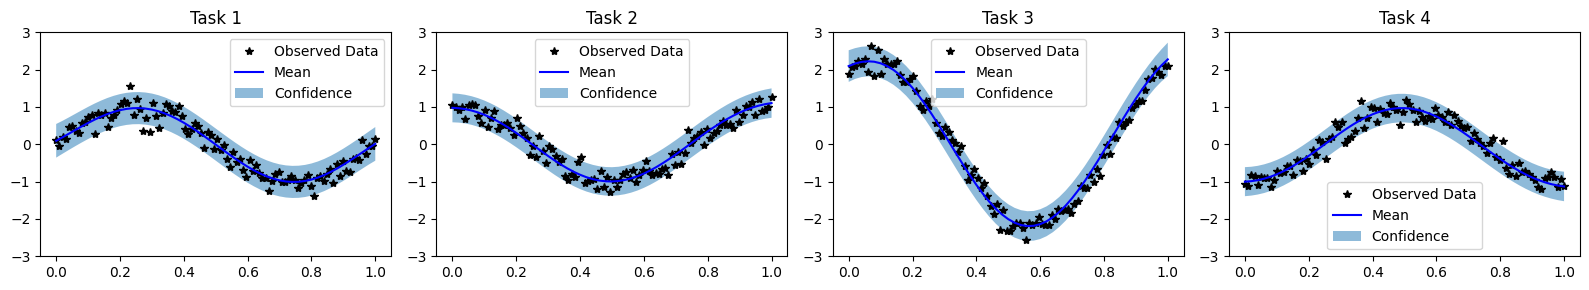

In [9]:
# Set into eval mode
model.eval()
likelihood.eval()

# Initialize plots
fig, axs = plt.subplots(1, num_tasks, figsize=(4 * num_tasks, 3))

# Make predictions
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, 1, 51)
    predictions = likelihood(model(test_x))
    mean = predictions.mean
    lower, upper = predictions.confidence_region()

for task, ax in enumerate(axs):
    # Plot training data as black stars
    ax.plot(train_x.detach().numpy(), train_y[:, task].detach().numpy(), 'k*')
    # Predictive mean as blue line
    ax.plot(test_x.numpy(), mean[:, task].numpy(), 'b')
    # Shade in confidence
    ax.fill_between(test_x.numpy(), lower[:, task].numpy(), upper[:, task].numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])
    ax.set_title(f'Task {task + 1}')

fig.tight_layout()
None